<a href="https://colab.research.google.com/github/volodymyr-holovan/DTA2026/blob/main/homework/practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/volodymyr-holovan/DTA2026/refs/heads/main/data/shop_customers.csv")
ab = pd.read_csv("https://raw.githubusercontent.com/volodymyr-holovan/DTA2026/refs/heads/main/data/ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [2]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [3]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [4]:
# Завдання 3:
mean_session = df['session_min'].mean()
print(f"Середній час на сайті: {mean_session:.2f} хв")

t_stat, p_value = stats.ttest_1samp(df['session_min'], 20)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.6g}")

Середній час на сайті: 20.74 хв
t-статистика: 1.570
p-значення: 0.117105


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Фактичний середній час на сайті — близько 20.7 хв, що дуже близько до заявлених маркетологом 20 хв. p-значення тесту (≈0.12) більше 0.05, тому ми НЕ відхиляємо H₀: статистично значущої різниці не виявлено. Отже, у цьому випадку маркетолог мав рацію — дані не дають підстав стверджувати, що реальний середній час на сайті відрізняється від 20 хвилин.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [5]:
# Завдання 4:
mean_spend = df['spend'].mean()
print(f"Середні витрати: {mean_spend:.2f} грн")

t_stat, p_value = stats.ttest_1samp(df['spend'], 850)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.4f}")

Середні витрати: 845.02 грн
t-статистика: -0.334
p-значення: 0.7384


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Середні витрати клієнтів становлять приблизно 845 грн, що дуже близько до заявлених керівником 850 грн. p-значення тесту (0.74) значно більше 0.05, тому ми НЕ відхиляємо H₀. Це означає, що дані не дають достатньо підстав стверджувати, що середні витрати відрізняються від 850 грн — спостережувана різниця (~5 грн) цілком узгоджується з випадковим розкидом вибірки.

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [6]:
# Завдання 5:
mobile_spend = df[df['device'] == 'Mobile']['spend']
desktop_spend = df[df['device'] == 'Desktop']['spend']

print(f"Середні витрати Mobile:  {mobile_spend.mean():.2f} грн")
print(f"Середні витрати Desktop: {desktop_spend.mean():.2f} грн")

t_stat, p_value = stats.ttest_ind(mobile_spend, desktop_spend)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.4f}")

Середні витрати Mobile:  835.21 грн
Середні витрати Desktop: 861.16 грн
t-статистика: -0.844
p-значення: 0.3993


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Клієнти з мобільних пристроїв витрачають в середньому трохи більше (≈861 грн), ніж клієнти з десктопу (≈835 грн), але p-значення (≈0.40) значно більше 0.05 — різниця статистично незначуща. Тобто на основі цих даних ми не можемо стверджувати, що мобільні клієнти дійсно витрачають більше: спостережена різниця в 26 грн цілком може бути випадковим розкидом вибірки. Тому радити компанії інвестувати саме в мобільну версію, спираючись лише на цей тест, — передчасно; потрібні додаткові дані або більша вибірка.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [7]:
# Завдання 6:
male_time = df[df['gender'] == 'Ч']['session_min']
female_time = df[df['gender'] == 'Ж']['session_min']

print(f"Середній час на сайті (Ч): {male_time.mean():.2f} хв")
print(f"Середній час на сайті (Ж): {female_time.mean():.2f} хв")

t_stat, p_value = stats.ttest_ind(male_time, female_time)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.4f}")

Середній час на сайті (Ч): 20.85 хв
Середній час на сайті (Ж): 20.63 хв
t-статистика: 0.232
p-значення: 0.8163


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [8]:
# Завдання 7:
print(f"Середня задоволеність ДО:     {df['sat_before'].mean():.2f}")
print(f"Середня задоволеність ПІСЛЯ:  {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df['sat_before'], df['sat_after'])
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.3g}")

Середня задоволеність ДО:     6.54
Середня задоволеність ПІСЛЯ:  7.14
t-статистика: -11.303
p-значення: 1.57e-26


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [9]:
# Завдання 8:
print(df.groupby('channel')['spend'].mean().round(2))

groups = [group['spend'].values for name, group in df.groupby('channel')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення: {p_value:.3g}")

channel
Органіка      791.28
Реклама      1057.87
Соцмережі     698.35
Name: spend, dtype: float64

F-статистика: 63.540
p-значення: 2.68e-25


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [10]:
# Завдання 9:
print(df.groupby('country')['session_min'].mean().round(2))

groups = [group['session_min'].values for name, group in df.groupby('country')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення: {p_value:.4f}")

country
Німеччина    21.29
Польща       21.17
Україна      20.29
Name: session_min, dtype: float64

F-статистика: 0.493
p-значення: 0.6111


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [11]:
# Завдання 10:
contingency = pd.crosstab(df['channel'], df['purchased'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2-статистика: {chi2:.3f}, ступені свободи: {dof}")
print(f"p-значення: {p_value:.3g}")

purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2-статистика: 0.957, ступені свободи: 2
p-значення: 0.62


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [12]:
# Завдання 11:
contingency = pd.crosstab(df['gender'], df['device'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2-статистика: {chi2:.3f}, ступені свободи: {dof}")
print(f"p-значення: {p_value:.4f}")

device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

chi2-статистика: 0.065, ступені свободи: 1
p-значення: 0.7993


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

r = 0.732
p-значення: 4.05e-85


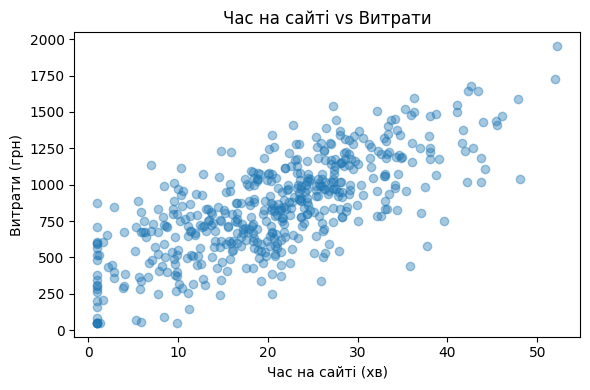

In [13]:
# Завдання 12:
r, p_value = stats.pearsonr(df['session_min'], df['spend'])
print(f"r = {r:.3f}")
print(f"p-значення: {p_value:.3g}")

plt.figure(figsize=(6, 4))
plt.scatter(df['session_min'], df['spend'], alpha=0.4)
plt.xlabel('Час на сайті (хв)')
plt.ylabel('Витрати (грн)')
plt.title('Час на сайті vs Витрати')
plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [14]:
# Завдання 13:
r, p_value = stats.pearsonr(df['age'], df['spend'])
print(f"r = {r:.3f}")
print(f"p-значення: {p_value:.4f}")

r = -0.042
p-значення: 0.3508


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [15]:
# Завдання 14:
ab['group'].value_counts()

,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [16]:
# Завдання 15:
conv_rates = ab.groupby('group')['converted'].mean()
print(conv_rates)

diff_pp = (conv_rates['B'] - conv_rates['A']) * 100
print(f"\nРізниця (B - A): {diff_pp:.2f} в.п.")

group
A    0.101
B    0.119
Name: converted, dtype: float64

Різниця (B - A): 1.80 в.п.


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [17]:
# Завдання 16:
contingency = pd.crosstab(ab['group'], ab['converted'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2-статистика: {chi2:.3f}, ступені свободи: {dof}")
print(f"p-значення: {p_value:.4f}")

converted     0    1
group               
A          3596  404
B          3524  476

chi2-статистика: 6.436, ступені свободи: 1
p-значення: 0.0112


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [18]:
# Завдання 17:
print(df.groupby('channel')['age'].mean().round(2))

groups = [group['age'].values for name, group in df.groupby('channel')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.3f}")
print(f"p-значення: {p_value:.4f}")

channel
Органіка     34.35
Реклама      35.43
Соцмережі    34.21
Name: age, dtype: float64

F-статистика: 0.599
p-значення: 0.5498


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [19]:
# Завдання 18:
mean_spend = df['spend'].mean()
print(f"Середні витрати: {mean_spend:.2f} грн")

t_stat, p_value = stats.ttest_1samp(df['spend'], 900)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення: {p_value:.3g}")

Середні витрати: 845.02 грн
t-статистика: -3.687
p-значення: 0.000252


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [20]:
# Завдання 19:
contingency = pd.crosstab(df['country'], df['device'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2-статистика: {chi2:.3f}, ступені свободи: {dof}")
print(f"p-значення: {p_value:.4f}")

device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

chi2-статистика: 1.207, ступені свободи: 2
p-значення: 0.5470


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [ ]:
# Завдання 20:


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
